# Setup and imports

In [1]:
%cd ..
from utils.setup import setup
from utils.model_analysis import look_at
from utils.dataset_handler import list_datasets, load_train_dataset, load_eval_benchmark

from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt


/home/sam/Projects/gemma-prover/src


In [2]:
setup()

Setup Complete


# Model Inspection

In [3]:
look_at("google/diffusiongemma-26B-A4B-it")

Model      : google/diffusiongemma-26B-A4B-it
Type       : diffusion_gemma / DiffusionGemmaForBlockDiffusion
Attn impl  : default (forced eager for inspection)
Activation : gelu_pytorch_tanh
Layer (type) [dims]                                                                                                   Params
----------------------------------------------------------------------------------------------------------------------------
DiffusionGemmaForBlockDiffusion (DiffusionGemmaForBlockDiffusion)                                                     25.82B
  model (DiffusionGemmaModel)                                                                                         25.82B
    encoder (DiffusionGemmaEncoderModel)                                                                              25.81B
      language_model (DiffusionGemmaEncoderTextModel)                                                                 25.23B
        embed_tokens (DiffusionGemmaTextScaledWordEmbedding

# Dataset

In [4]:
ds = load_train_dataset()
n = len(ds)

DataFrame(ds[:3])

,header,statement,proof,text
0,import Mathlib\nimport Aesop\nset_option maxHe...,"theorem p147_3_2 (f : ℝ → ℝ) (hf: ∀ x y, f x *...",apply Iff.intro\n intro h\n use 1\n have ...,import Mathlib\nimport Aesop\nset_option maxHe...
1,import Mathlib\nimport Aesop\nset_option maxHe...,theorem lean_workbook_122941 (x : ℝ) (hx : x ∈...,"have h : ∀ i ∈ Finset.range n, (1 : ℝ) / (i ...",import Mathlib\nimport Aesop\nset_option maxHe...
2,import Mathlib\nimport Aesop\nset_option maxHe...,theorem amc12b_2015_p11_2 (a : ℝ) (h₀ : 0 < a ...,have h₂ : 0 < Real.sqrt 3 := Real.sqrt_pos.m...,import Mathlib\nimport Aesop\nset_option maxHe...


In [5]:
headers = ds["header"]
empty = sum(1 for h in headers if h == "")
normal = n - empty

print(f"Empty header:  {empty}/{n} ({100 * empty / n:.2f}%)")
print(f"Non-empty header: {normal}/{n} ({100 * normal / n:.2f}%)")

Empty header:  0/3319811 (0.00%)
Non-empty header: 3319811/3319811 (100.00%)


In [6]:
statements = ds["statement"]
ends = sum(1 for s in statements if s.endswith(":= by"))
not_ends = n - ends

print(f"Ends with ':= by':  {ends}/{n} ({100 * ends / n:.2f}%)")
print(f"Does not:           {not_ends}/{n} ({100 * not_ends / n:.2f}%)")

Ends with ':= by':  2811230/3319811 (84.68%)
Does not:           508581/3319811 (15.32%)


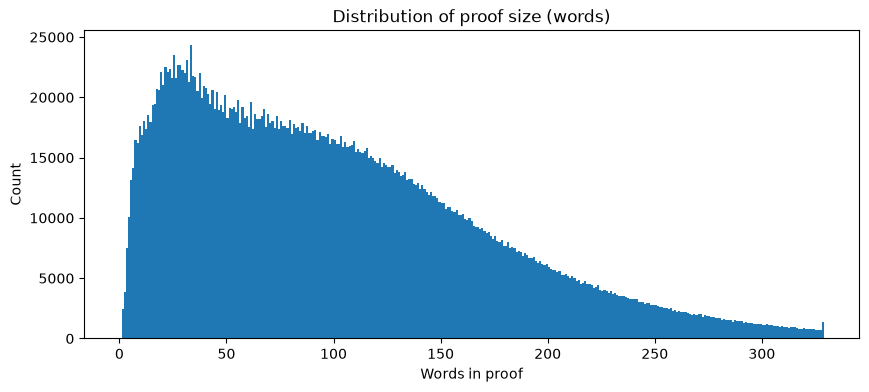

In [7]:
proof_words = [len(p.split()) for p in ds["proof"]]
hi = int(np.percentile(proof_words, 99))

plt.figure(figsize=(10, 4))
plt.hist(proof_words, bins=range(0, hi + 2))
plt.xlabel("Words in proof")
plt.ylabel("Count")
plt.title("Distribution of proof size (words)")
plt.show()